In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

from scipy.sparse.linalg import eigsh, expm_multiply, LinearOperator
from scipy.linalg import eigh, eigh_tridiagonal

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
def make_hermitian_sparse_random(size: int, density: float, seed: int = 42) -> sp.csr_matrix:
    rng = np.random.default_rng(seed)
    H = sp.random(size, size, density=density, format="csr", dtype=np.complex128, random_state=rng)
    H = H + H.conj().T
    return H.tocsr()

In [3]:
H = make_hermitian_sparse_random(100, 0.1)

In [4]:
# Get the full spectrum using dense methods
eigenvalues, eigenvectors = eigh(H.toarray())

In [6]:
eigenvectors.shape

(100, 100)

In [20]:
def increase_space(H, eigenvectors, iterations):
    # Check that eigenvectors has shape H.shape
    assert eigenvectors.shape[0] == H.shape[0], "Eigenvectors must have the same number of rows as H"

    H_new = eigenvectors.conj().T @ H @ eigenvectors
    eigenvalues_new, _ = eigh(H_new)

    energies = [eigenvalues_new[0]]  # Start with the GS energy in the original space
    for i in range(iterations):
        # Dublicate some random eigenvectors
        new_vectors = eigenvectors[:, np.random.choice(eigenvectors.shape[1], size=10, replace=False)]
        eigenvectors = np.hstack((eigenvectors, new_vectors))

        # Now build the new Hamiltonian in the enlarged space
        # We will use the original H and project it onto the new space spanned by the eigenvectors
        H_new = eigenvectors.conj().T @ H @ eigenvectors
        # Get the eigenvalues of the new Hamiltonian
        eigenvalues_new, _ = eigh(H_new)
        # Append the GS energy
        energies.append(eigenvalues_new[0])

    return energies

In [21]:
energies = increase_space(H, eigenvectors, iterations=20)

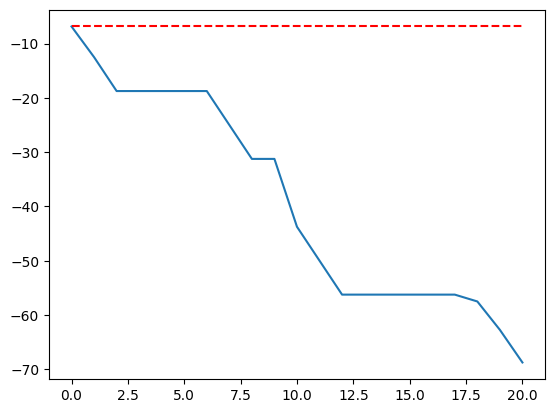

In [22]:
plt.plot(energies)
plt.plot(eigenvalues[0] * np.ones_like(energies), 'r--', label='Exact GS Energy')